> This script is deigned to be used with conda env
> crime_weather_env

ETL pipeline at [combine_crime_ceda_data.py](../combine_crime_ceda_data.py).  
Cluser labels generated at [spatial_clustering.ipynb](../1_spatial_clusters/spatial_clustering.ipynb).  
Context labels applied at [context_lables.ipynb](../2_context_lables/context_lables.ipynb)


# Logistic Regression

This script applies logistic regression on the 'Leisure' and 'Retail' cluster datasets to test the project hypotheses.

These are:

 - **HO, Null hypothesis**:   
    "The maximum ambient temperature (tasmax) and relative humidity (hurs) have no statistically significant effect on the odds of a crime occuring in a Leiure cluster versus a Retail cluster. Spatial distrubtions of crime occurence across land use contexts is independent of weather variables."  
      
 - **H1, Alternative hypothesis**:  
    "Increases in maximum ambient air temperature and humidity significantly increase the odds of a crime occuring in a Leisure cluster versus a retail cluster."   

Background Reading:  
[A.L Nelson, R.D.F Bromley & C.J Thomas (2000)](https://doi.org/10.1016/S0143-6228(01)00008-X)  
[Brunsdon, C., Corcoran, J., Higgs, G. & Ware, A. (2009).](https://doi.org/10.1068/b32133)  
[Narushige Shiode, Shino Shiode, Hayato Nishi & Kimihiro Hino (2023)](https://doi.org/10.1007/s43762-023-00094-x)  

## Import modules

In [45]:
# standard libraries
import os
from pathlib import Path

# other libraries
import duckdb

# typers and submodules
from duckdb import DuckDBPyConnection
from pandas import DataFrame


## Directories, db and Path Setup

In [2]:
cwd: str = os.getcwd()
data_dir: Path = Path(cwd).parent / 'data' / 'police_archives'
crime_db: Path = data_dir/'crime_archive.db'

Connect to the duckdb

In [3]:
con: DuckDBPyConnection = duckdb.connect(database=crime_db)

Introspect

In [4]:
# introspect
con.execute(query="SHOW TABLES").fetchall()

[('crimetology_NS',),
 ('crimetology_NS_clean',),
 ('crimetology_coords_lookup',),
 ('street_data',)]

In [6]:
con.execute(query="SELECT * FROM crimetology_NS_clean LIMIT 2;").df()


,Crime ID,Month,Longitude,Latitude,Crime type,tasmax,tas,groundfrost,sun,snowLying,tasmin,rainfall,hurs,sfcWind,Cluster ID,Crime Bucket,Cluster Label
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,2020-01,0.521596,52.345789,Violence and sexual offences,9.597225,6.834480,8.521248,57.155247,0.028889,4.043394,46.032112,88.652786,4.317238,869,OTHER,Other
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,2020-01,1.188665,52.041702,Violence and sexual offences,9.253441,6.699946,12.421773,53.776817,0.017040,4.145340,42.233070,88.948593,4.330167,5065,OTHER,Other


# Extract features

Need to keep in-memory data footprint reasonable

In [8]:
feature_query = """SELECT "Crime ID",
                          "Cluster Label",
                          "tasmax",                                        --Independent variable 1
                          "hurs"                                           --Independent varibale 2
                          FROM crimetology_NS_clean 
                          WHERE "Cluster Label" IN ('Leisure','Retail');   --Dependent variable
                """


In [10]:
features_df: DataFrame = con.execute(query=feature_query).df()
features_df

,Crime ID,Cluster Label,tasmax,hurs
0,42a431be7080b174dc6a6fe419678ae1c6e2a81afc82d6...,Leisure,8.992604,89.899658
1,f92c6b203564a084e8ec1ae523433302ca903f9783c89f...,Retail,9.033701,88.757492
2,728733ef4da4abf89f8a83b3f1104d1142683febcfefc7...,Leisure,9.201315,88.917358
3,f183e986bb0043037d40b5848c7d66bacd570eecf7a9c4...,Retail,9.237802,89.107567
4,08059176f2ca15ed52158c38966df742603f12105e5942...,Retail,9.297161,89.673691
...,...,...,...,...
43929,72c74647c90095c29306baba145140affcb7aaa00ca953...,Leisure,21.899710,78.565903
43930,b01fe8dc3c05f6436741f4e67f68cb19426db26763ae01...,Retail,21.902161,79.977829
43931,7d4a1dca0d15ac78d98770d23d604c0391df74e2f2e2a2...,Retail,21.902161,79.977829
43932,efe28a09d0b076e396b4e775ca9ccf78b0ee73c3095d64...,Retail,21.902161,79.977829


This yields 43934 rows of data for the logistic regression. 

## Initial EDA

Need to:

1. Make sure no nulls and data size is ok
1. Duplicate rows dont exist
1. Check ratio of binary target categories (1='Leisure',0='Retail')  
1. Check correlation between max temp and humidity, the predictors

features_df.notnull().sum()


In [11]:
sum(features_df.duplicated())

0

<Axes: xlabel='Cluster Label'>

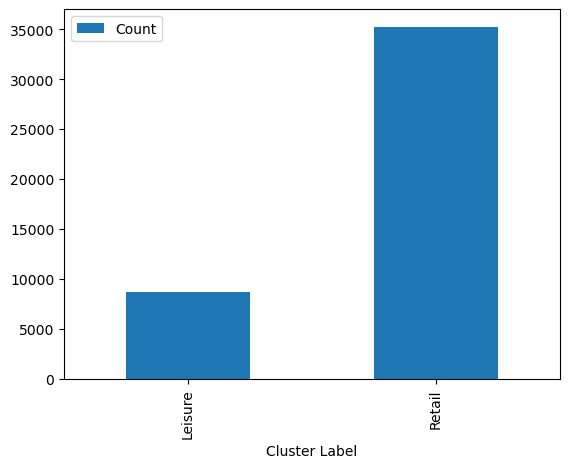

In [17]:
features_df.drop(columns=['tasmax','hurs']).groupby(by='Cluster Label').agg(func='count').rename(columns={"Crime ID":"Count"}).plot.bar()

In [36]:
## ratio is
counts: DataFrame = features_df.drop(columns=['tasmax','hurs']).groupby(by='Cluster Label').agg(func='count').rename(columns={"Crime ID":"Count"})

print(f"Ratio of binary target is 1:{round(number=(counts.iloc[1]/counts.iloc[0]).values[0],ndigits=2)}")



Ratio of binary target is 1:4.06


In [38]:
features_df.shape[0]/5.06

8682.608695652174

**Note** there are around 8000 samples for Leisure, this is ok.

In [37]:
features_df[["tasmax","hurs"]].corr()

,tasmax,hurs
tasmax,1.000000,-0.736143
hurs,-0.736143,1.000000


**Note** there is a relatively strong negative corellation between tasmax and relative humidity.    
**THIS MAY IMPACT THE REGRESSION**, it may be better to run a univariate method on tasmax and hurs one by one as they may compete with one another in the regression. 

In [41]:
features_df["tasmax"].describe()

count    43934.000000
mean        15.515731
std          5.700316
min          5.069943
25%         10.335984
50%         15.210895
75%         20.734396
max         27.177244
Name: tasmax, dtype: float64

<Axes: >

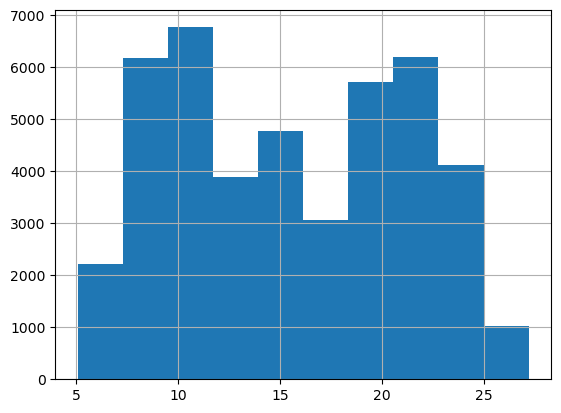

In [43]:
features_df["tasmax"].hist()

In [42]:
features_df["hurs"].describe()

count    43934.000000
mean        79.703865
std          6.608034
min         60.232498
25%         74.843475
50%         79.869659
75%         85.473717
max         93.945518
Name: hurs, dtype: float64

<Axes: >

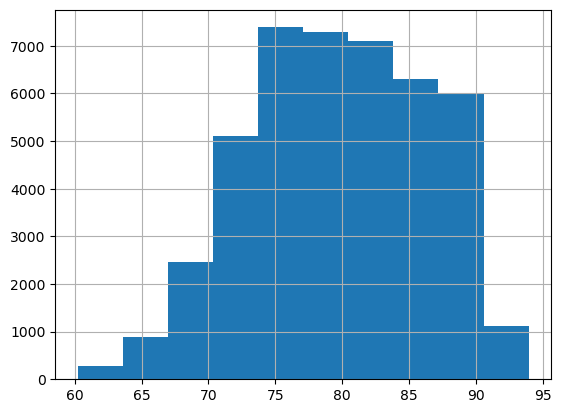

In [44]:
features_df["hurs"].hist()

**Note**: no extreme outliers are present so looks generally ok. Temperature has a seasonality pesent via the bimodial distrubution in the hist, but this is ok for log(odds).